# Ray tracing simulation # 

In [1]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna
from importlib.metadata import version
print("Sionna version:", version("sionna"))

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']
Sionna version: 2.0.0


In [111]:
# Import scene as xml file
scene = load_scene("WindowsConfig/WindowsConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())
print(scene.rx_array.positions(3e8/3.5e9))

# Tx position
TX_position = [-7, 3.5, 1.5]

tx = Transmitter("tx", TX_position)
# scene.add(tx)

# Rx positions
num_rx = 8
RX_positions = [[-8, 10, 1.5], 
                [0, 8, 1.5], 
                [8, 10, 1.5], 
                [9, 0, 1.5], 
                [-9, 0, 1.5], 
                [-8, -10, 1.5], 
                [0, -8, 1.5], 
                [8, -10, 1.5]]

num_rx = 4
RX_positions = [[-8, 10, 1.5], 
                [8, 10, 1.5],
                [-8, -10, 1.5],
                [8, -10, 1.5]]

RX_orientations = [[-np.pi/4, 0, 0], 
                   [-np.pi/2, 0, 0], 
                   [-3*np.pi/4, 0, 0], 
                   [np.pi, 0, 0], 
                   [0, 0, 0], 
                   [np.pi/4, 0, 0], 
                   [np.pi/2, 0, 0], 
                   [3*np.pi/4, 0, 0]]

RX_orientations = [[-np.pi/2, 0, 0], 
                    [-np.pi/2, 0, 0], 
                    [np.pi/2, 0, 0],
                    [np.pi/2, 0, 0]]

rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
# rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
# rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
# rx7 = Receiver("rx7", RX_positions[6], RX_orientations[6])
# rx8 = Receiver("rx8", RX_positions[7], RX_orientations[7])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
# scene.add(rx5)
# scene.add(rx6)
# scene.add(rx7)
# scene.add(rx8)

scene.preview()

no-name-37     itu-concrete
elm__7         itu-glass
Directivity [dB]: 1.76
Gain [dB]: 1.76
Efficiency [%]: 1e+02
([1.49999], [1.5], [1.00001])
[[0, -0.0642857, 0],
 [0, -0.0214286, 0],
 [0, 0.0214286, 0],
 [0, 0.0642857, 0]]


TraitError: The 'rotation' trait of a PerspectiveCamera instance contains an Enum of an Euler which expected any of ['XYZ', 'YZX', 'ZXY', 'XZY', 'YXZ', 'ZYX'], not the str 'xyz'.

TraitError: The 'rotation' trait of a PerspectiveCamera instance contains an Enum of an Euler which expected any of ['XYZ', 'YZX', 'ZXY', 'XZY', 'YXZ', 'ZYX'], not the str 'xyz'.

In [74]:
### System parameters ###

# Band sampling parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000

### Paths computations ###

In [75]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.2 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [76]:
scene.preview(paths=paths)

[-0. -0. -0. -0.]
[ 0.         -2.84458768  0.59401007 -2.25057759]
[-0. -0. -0. -0.]
[-0.          2.0550758  -2.17303414 -0.11795838]


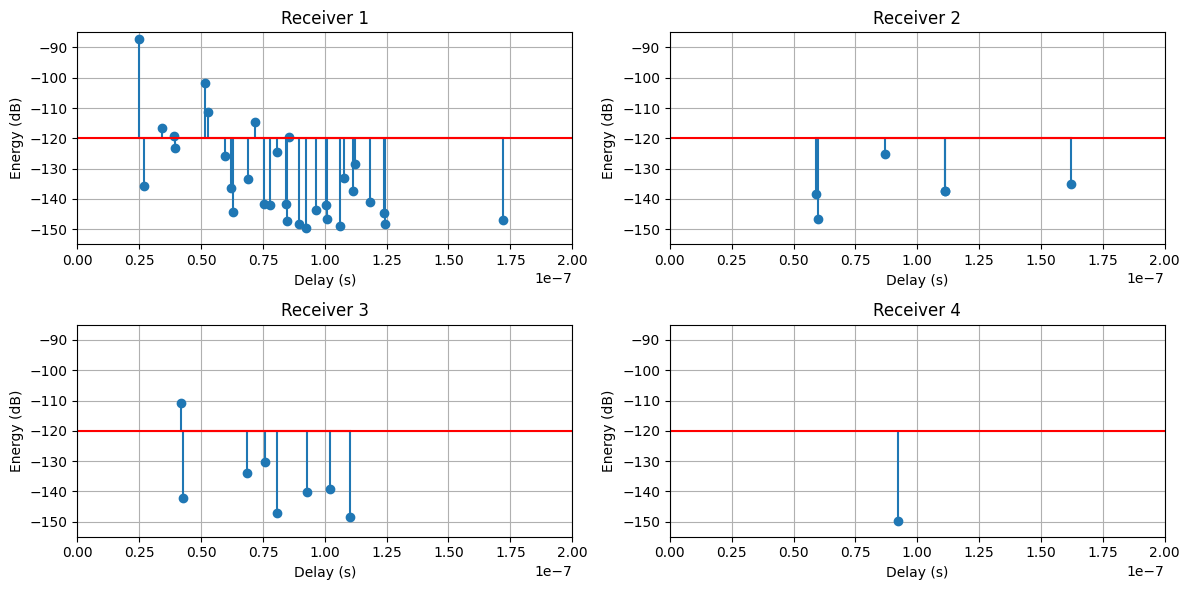

In [77]:
importlib.reload(util)

# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)

angles = paths.phi_r

a, tau, angles = util.format_paths(cir, angles, array=True)

# Scale a with transmit power
a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

for i in range(len(a)):
    print(np.angle(a[i][:, 0] / a[i][0, 0]))

# Energy of paths
magnitudes = [np.abs(a[i]) for i in range(num_rx)]
energies = [magnitudes[i]**2 for i in range(num_rx)]


# Filter paths too weak
threshold = -150 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(num_rx):
    mask = energies[i] >= threshold_lin
    a[i] = a[i][mask].reshape(num_rx_ant, -1)
    tau[i] = tau[i][mask[0]]
    angles[i] = angles[i][mask[0]]
    magnitudes[i] = magnitudes[i][mask].reshape(num_rx_ant, -1)
    energies[i] = energies[i][mask].reshape(num_rx_ant, -1)


plt.figure(figsize=(12, 6))
for i in range(num_rx):
    plt.subplot(2, num_rx//2, i+1)
    plt.stem(tau[i], 10*np.log10(energies[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim(0, 2e-7)
    plt.ylim(-155, -85)
    plt.grid()
plt.tight_layout()

7.81183926183673e-09
7.774356288563925e-09


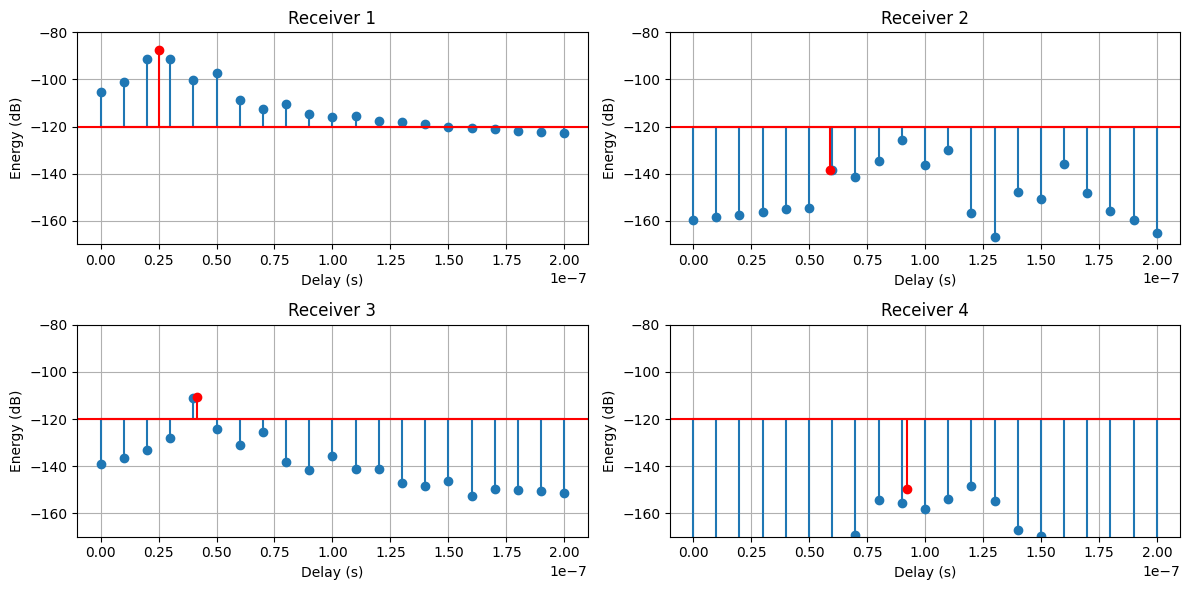

In [78]:
# Channel impulse response of the path
l_min, l_max = 0, 20
t = np.arange(l_min, l_max+1) / B

taps = paths.taps(bandwidth=B, l_min=l_min, l_max=l_max, normalize_delays=False)
taps_re, taps_im = taps[0], taps[1]
taps_re = taps_re.numpy().reshape(taps_re.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_im = taps_im.numpy().reshape(taps_im.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_lin = taps_re + 1j * taps_im
taps_mag = np.sqrt(taps_re**2 + taps_im**2)
taps_energy = taps_mag ** 2


print(np.sum(taps_energy[0]))
print(np.sum(energies[0]))


plt.figure(figsize=(12, 6))
for i in range(num_rx):
    plt.subplot(2, num_rx//2, i+1)
    plt.stem(t, 10*np.log10(taps_energy[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.stem(tau[i][0], 10*np.log10(energies[i][0][0]), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='ro', label='Path Energies')
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim((l_min-1)/B, (l_max+1)/B)
    plt.ylim(-170, -80)
    plt.grid()
plt.tight_layout()

In [79]:
import Multipath as mp
import Comm as com
importlib.reload(mp)
importlib.reload(com)


fft_size = 256
RX_idx = 3
music_spectrum, music_tau, music_angle, K, estimated_channel = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
# music_a, music_taus = mp.MUSIC_taps_time(music_spectrum, music_tau, B/fft_size, estimated_channel)


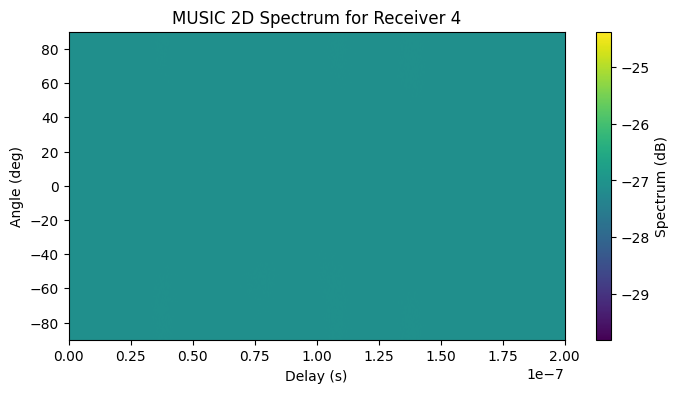

In [80]:
local_angles = util.format_local_angles(angles, RX_orientations)

plt.figure(figsize=(8, 4))
plt.imshow(10*np.log10(music_spectrum.T), extent=(music_tau[0], music_tau[-1], music_angle[0]*180/np.pi, music_angle[-1]*180/np.pi), aspect='auto', origin='lower')
# plt.scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
plt.title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Angle (deg)")
plt.colorbar(label='Spectrum (dB)')
plt.show()

Optimal number of paths: 0


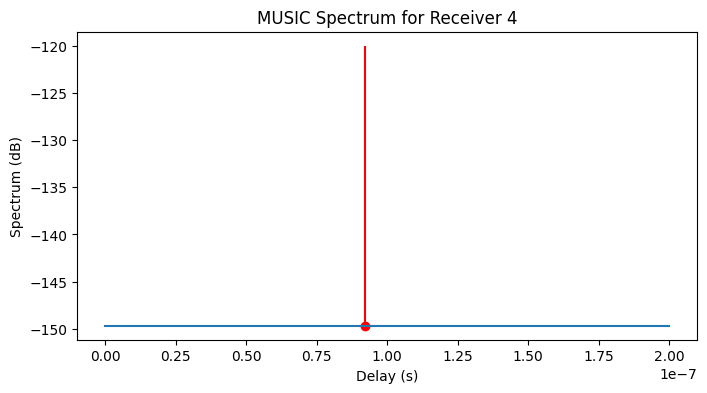

In [81]:
importlib.reload(mp)
importlib.reload(com)

music_spectrum, music_tau, K, estimated_channel = mp.MUSIC_spectrum(a[RX_idx][0], tau[RX_idx], B, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)

plt.figure(figsize=(8, 4))
plt.stem(tau[RX_idx], 10*np.log10(energies[RX_idx][0]), markerfmt='ro', linefmt='r-', label='True Path Energies', bottom=10*np.log10(S_RX_lin))
plt.plot(music_tau, 10*np.log10(music_spectrum*np.max(energies[RX_idx][0])/np.max(music_spectrum)), label='MUSIC Spectrum')
plt.title(f"MUSIC Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Spectrum (dB)")
plt.show()

In [82]:
importlib.reload(mp)
importlib.reload(com)

music_spectrums = []
music_taus = []
music_angles = []
music_Ks = []
music_h_hats = []
for RX_idx in range(num_rx):
    music_spectrum, music_tau, music_angle, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
    music_spectrums.append(music_spectrum)
    music_taus.append(music_tau)
    music_angles.append(music_angle)
    music_Ks.append(music_K)
    music_h_hats.append(music_h_hat)

C:\Users\louis\AppData\Local\Temp\ipykernel_6556\2976018842.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[RX_idx//2, RX_idx%2].legend()


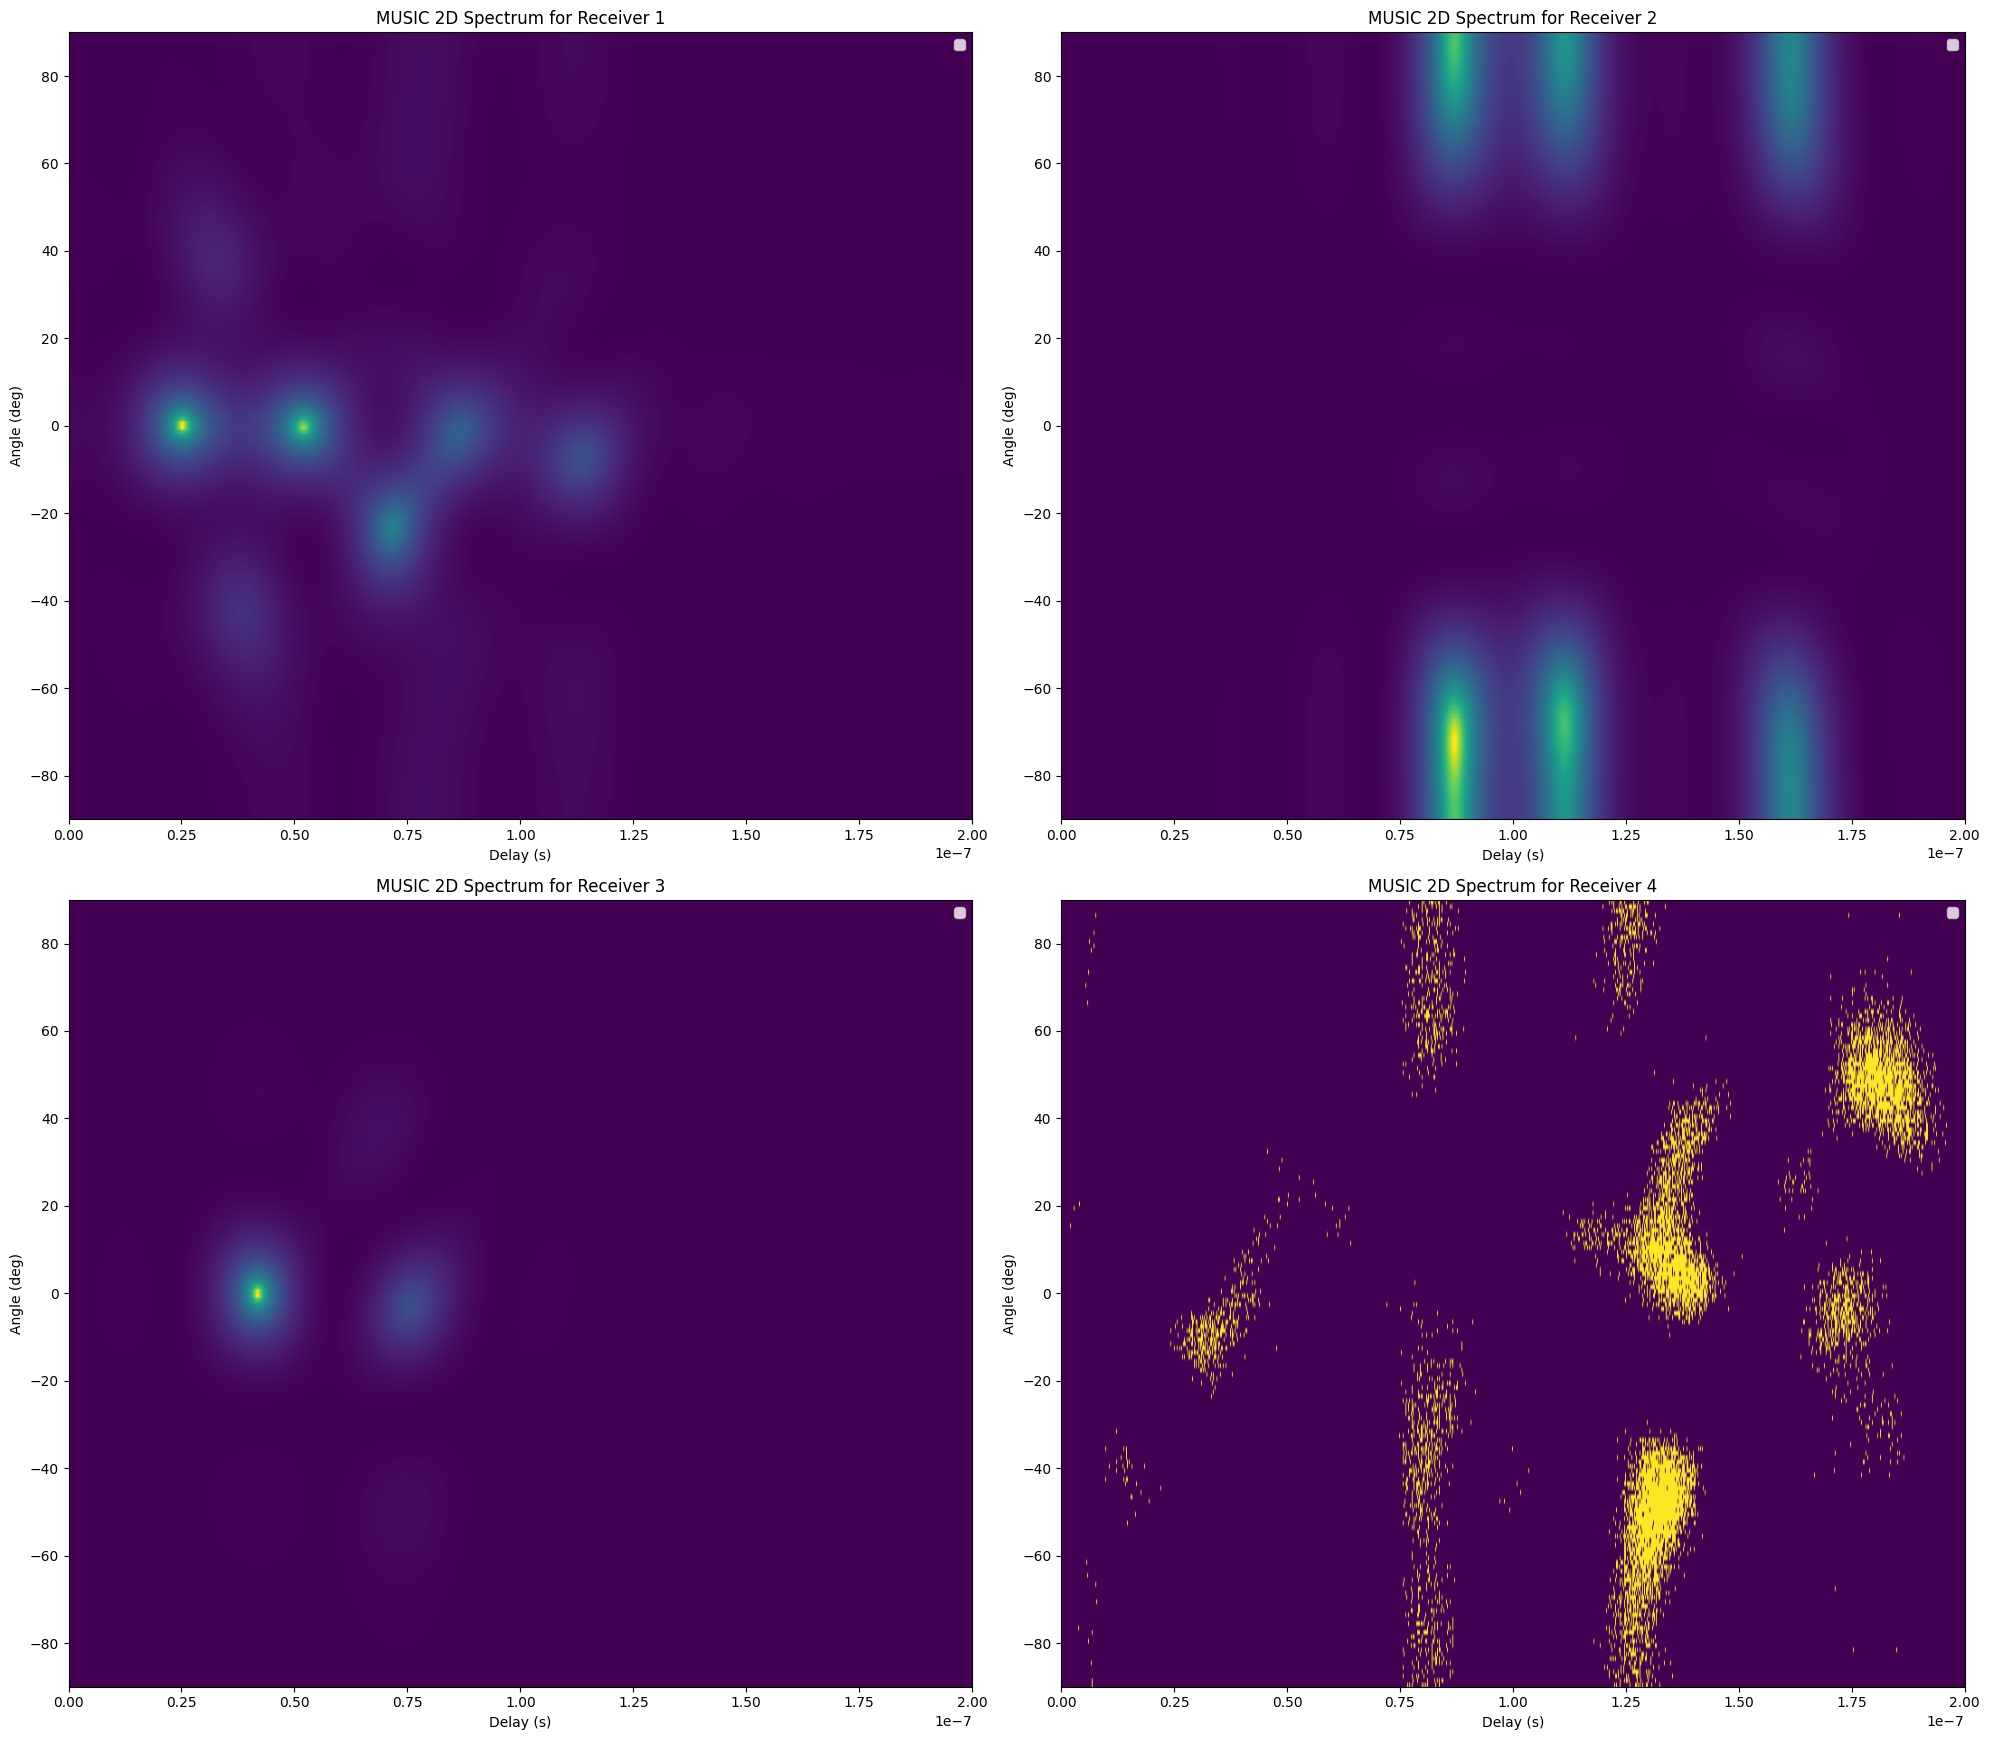

In [83]:
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 35/8*num_rx))
for RX_idx in range(num_rx):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles[RX_idx][0]*180/np.pi, music_angles[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower')
    # ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

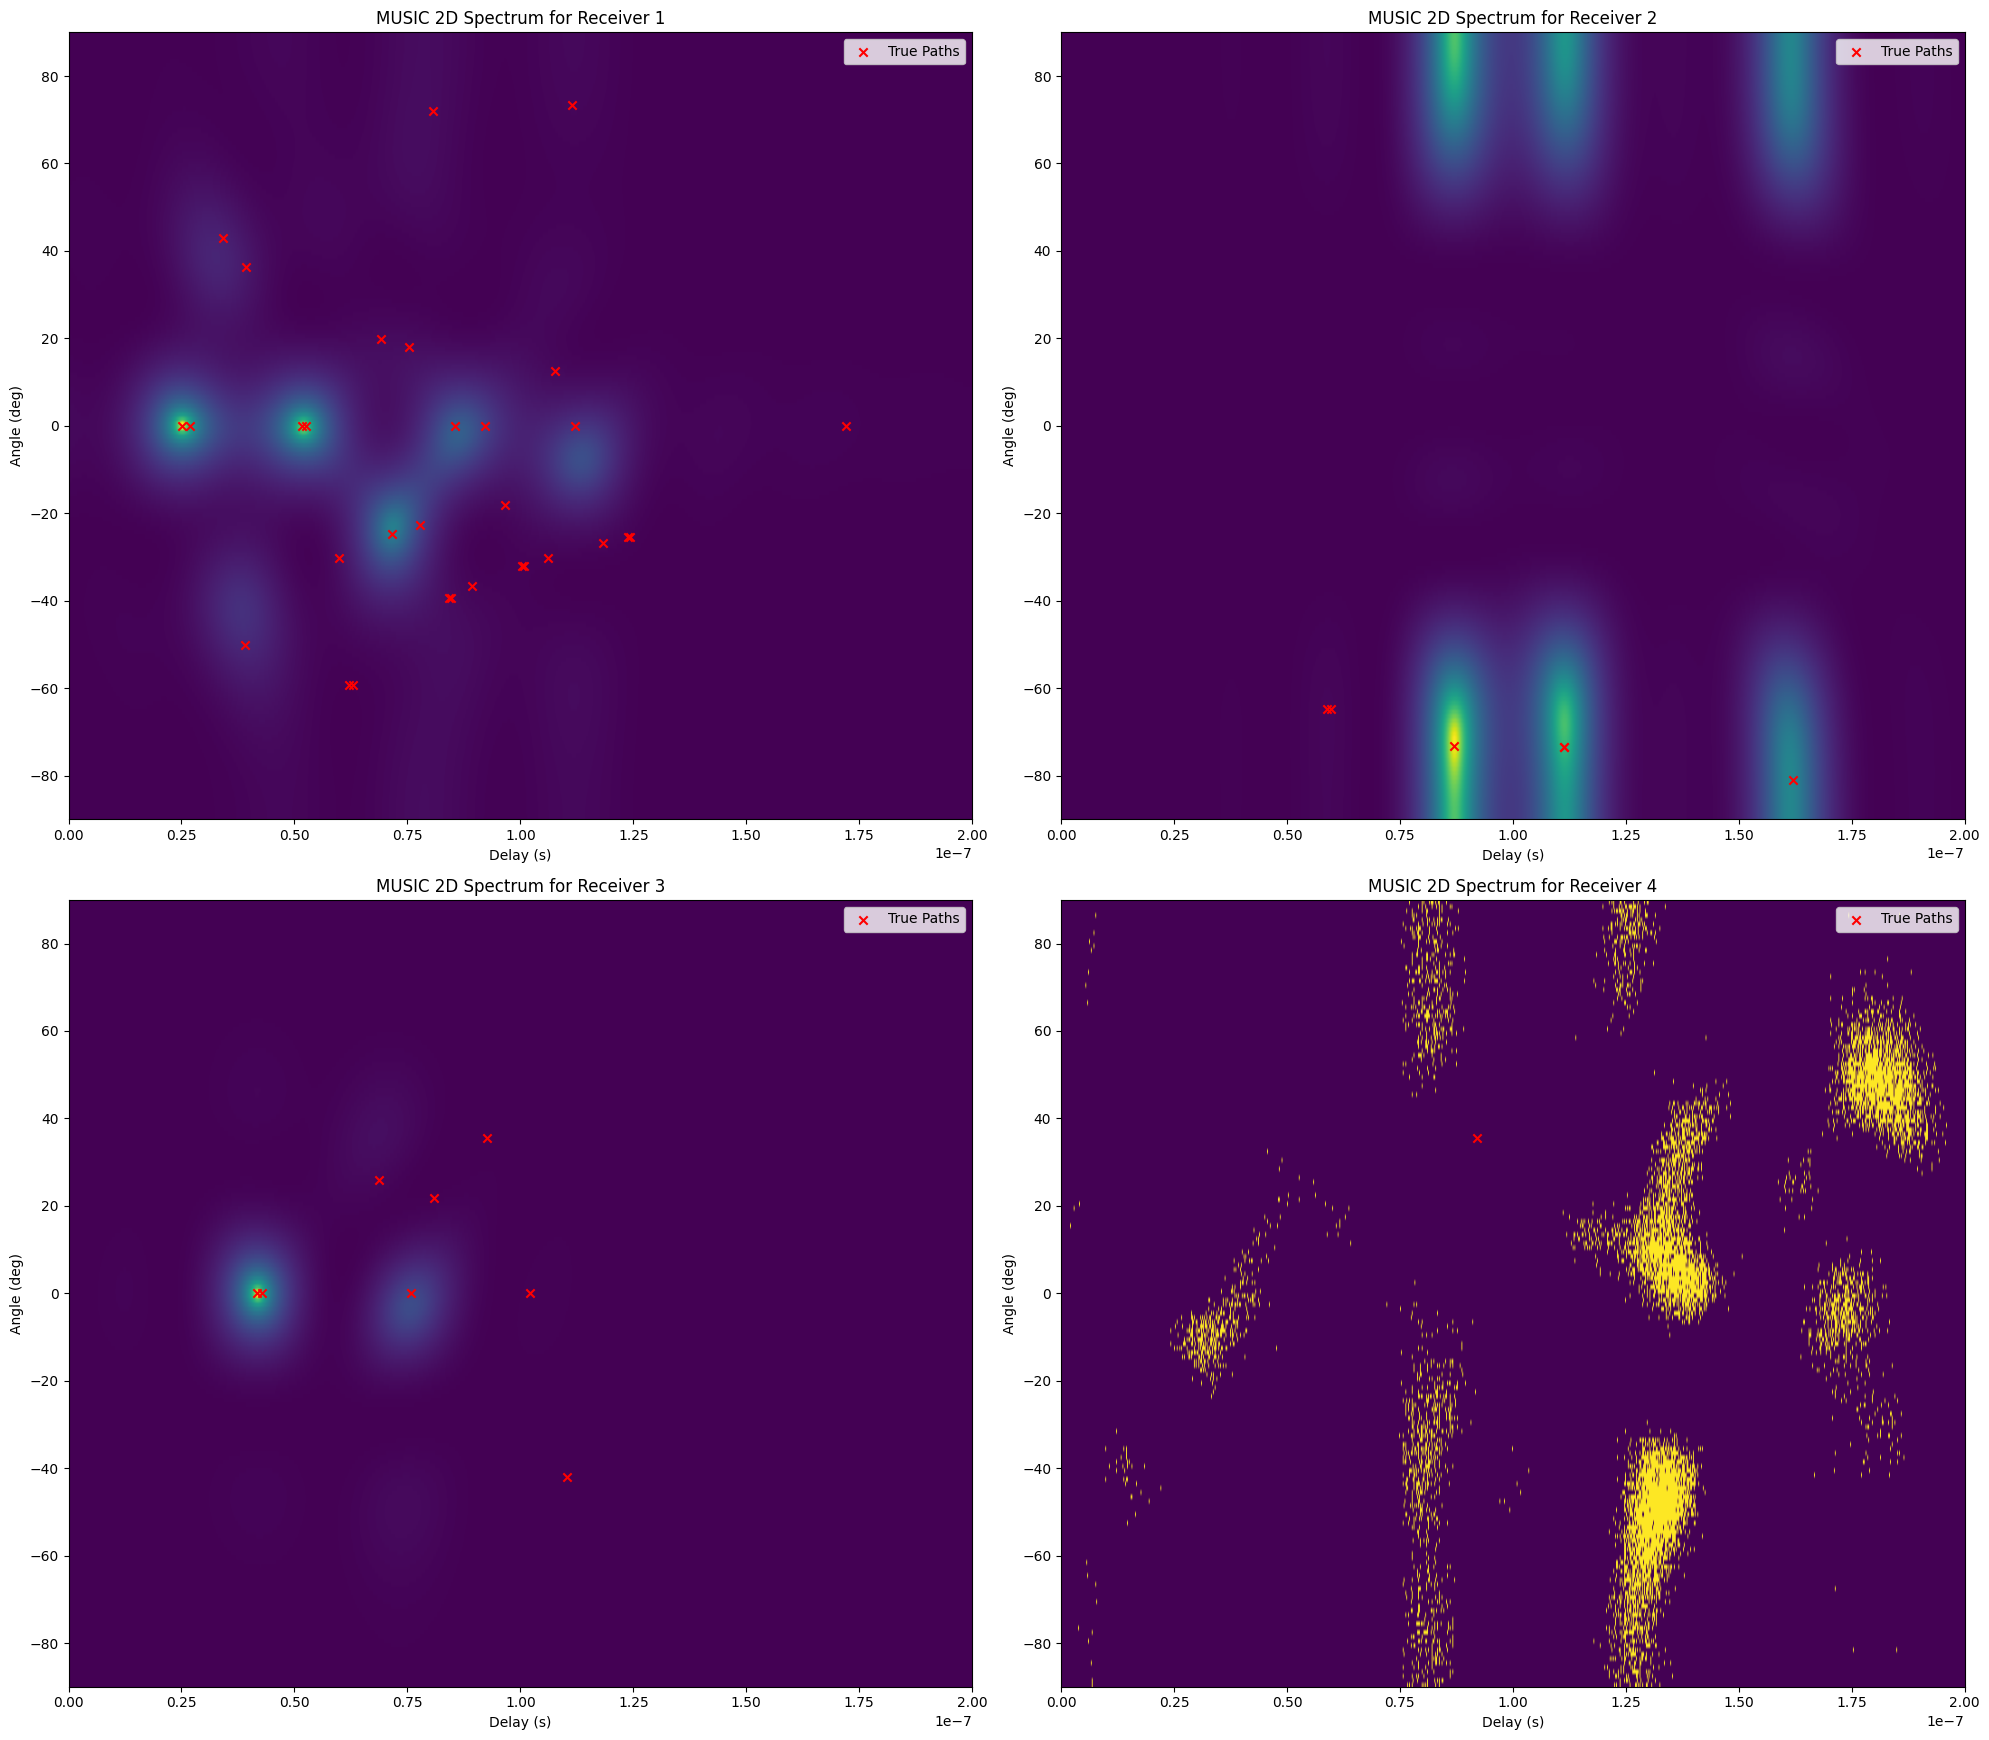

In [84]:
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 35/8*num_rx))
for RX_idx in range(num_rx):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles[RX_idx][0]*180/np.pi, music_angles[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower')
    ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

In [85]:
importlib.reload(mp)

taps_hat = []
taus_hat = []
angles_hat = []
print(music_spectrums[0].shape)
for RX_idx in range(num_rx):
    music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                music_taus[RX_idx], 
                                                                                music_angles[RX_idx], 
                                                                                B/fft_size, 
                                                                                music_Ks[RX_idx], 
                                                                                music_h_hats[RX_idx])
    taps_hat.append(music_taps)
    taus_hat.append(music_estimated_taus)
    angles_hat.append(music_estimated_angles)


(1000, 180)


C:\Users\louis\AppData\Local\Temp\ipykernel_6556\2050734296.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[RX_idx//2, RX_idx%2].legend()


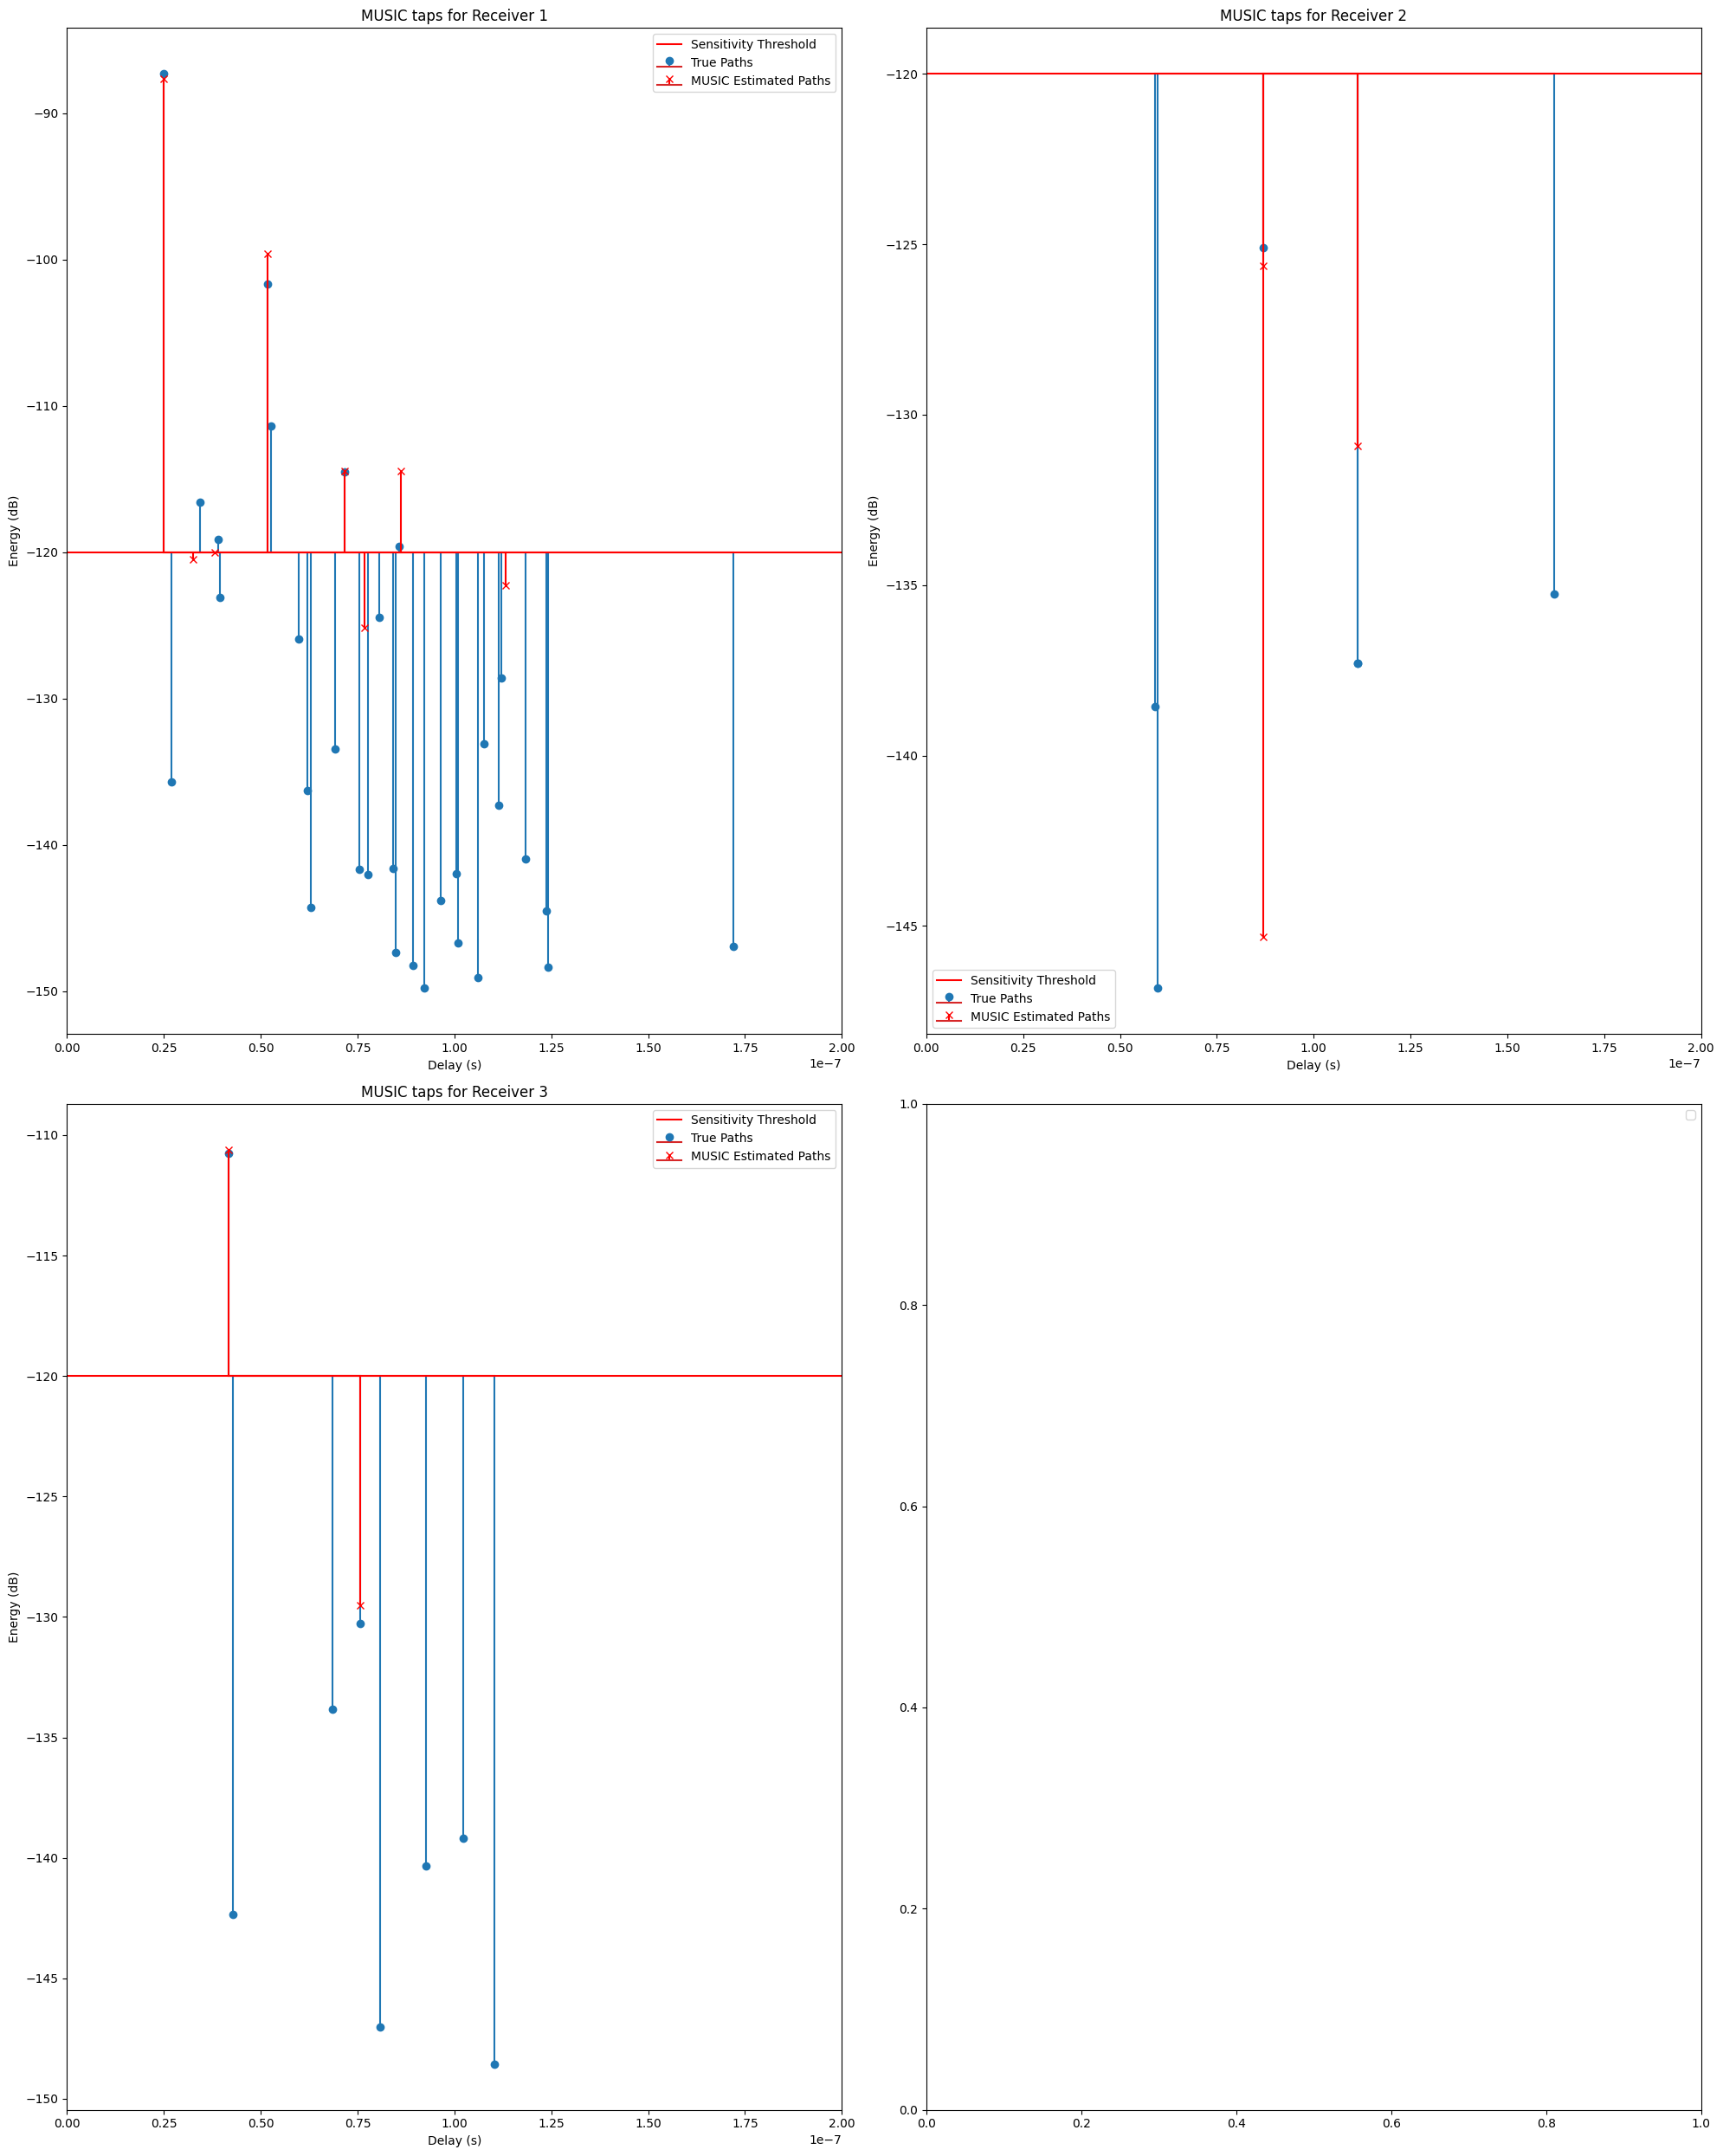

In [86]:
# Comparison of true vs estimated taps for one receiver
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 25))
for RX_idx in range(num_rx):
    if len(taps_hat[RX_idx]) > 0:
        ax[RX_idx//2, RX_idx%2].stem(tau[RX_idx], 10*np.log10(energies[RX_idx][0]), bottom=10*np.log10(S_RX_lin), label='True Paths')
        ax[RX_idx//2, RX_idx%2].stem(taus_hat[RX_idx], 10*np.log10(np.abs(taps_hat[RX_idx])**2), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='rx', label='MUSIC Estimated Paths')
        ax[RX_idx//2, RX_idx%2].axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
        ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC taps for Receiver {RX_idx+1}")
        ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
        ax[RX_idx//2, RX_idx%2].set_ylabel("Energy (dB)")
        ax[RX_idx//2, RX_idx%2].set_xlim(0, 2e-7)
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()


In [87]:
import Aoa
import Tdoa
import Hybrid
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)
importlib.reload(util)

true_first_toas = [tau[RX_idx][0] if len(tau[RX_idx]) > 0 else -1 for RX_idx in range(num_rx)]
true_first_aoas = [angles[RX_idx][0] if len(angles[RX_idx]) > 0 else 4 for RX_idx in range(num_rx)]

first_toas = np.zeros(num_rx)
for RX_idx in range(num_rx):
    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
    first_toas[RX_idx] = first_toa

first_aoas = np.zeros(num_rx)
for RX_idx in range(num_rx):
    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])


# Manual correction of wrong estimates
valid_Rxs = [True for _ in range(num_rx)]
# valid_Rxs[2] = False



# for RX_idx in range(num_rx):
#     print(f"Receiver {RX_idx+1}:")
#     print(f"  True First ToA: {true_first_toas[RX_idx]:.2e} s, Estimated First ToA: {first_toas[RX_idx]:.2e} s")
#     print(f"  True First AoA: {true_first_aoas[RX_idx]*180/np.pi:.2f} deg, Estimated First AoA: {first_aoas[RX_idx]*180/np.pi:.2f} deg")


# TDOA localization using first path
TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer2 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer3 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer4 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)

position_estimate_tdoa = TdoaLocalizer.localize()
position_estimate_tdoa2 = TdoaLocalizer2.localize_least_squares()
position_estimate_tdoa3, residuals_record = TdoaLocalizer3.localize_weighted_least_squares(iter=2)
# position_estimate_tdoa4 = TdoaLocalizer4.localize_iterative_outlier_removal(iter=2)
print("TDOA Position Estimate:", position_estimate_tdoa)
print("TDOA Least Squares Position Estimate:", position_estimate_tdoa2)
print("TDOA Weighted Least Squares Position Estimate:", position_estimate_tdoa3)
# print("TDOA Iterative Outlier Removal Position Estimate:", position_estimate_tdoa4)

# Filtering
errors = first_toas*3e8 - np.linalg.norm(np.array(RX_positions)[:,:2] - position_estimate_tdoa2, axis=1)
errors2 = TdoaLocalizer2.detect_outliers(position_estimate_tdoa2)
print("Receiver errors (m):", errors)
print("Receiver errors2 (m):", errors2)

# fig, ax = plt.subplots(1, residuals_record.shape[1], figsize=(20, 5))
# for i in range(residuals_record.shape[1]):
#     ax[i].plot(np.abs(residuals_record[:, i]))
#     ax[i].set_title(f"Residuals for TDoA {i+1}")
#     ax[i].set_xlabel("Iteration")
#     ax[i].set_ylabel("Residual (m)")
# plt.tight_layout()
# plt.show()

# for RX_idx in range(num_rx):
#     print(f"Rx position: {RX_positions[RX_idx][:2]}")
#     print(f"Distance measured from toa: {first_toas[RX_idx]*3e8:.2f} m")
#     print(f"Actual distance from target: {np.linalg.norm(np.array(RX_positions[RX_idx][:2]) - np.array(TX_position[:2])):.2f} m")


# AOA localization using first path
AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
position_estimate_aoa = AoaLocalizer.localize()
position_estimate_aoa2 = AoaLocalizer.localize_least_squares()
print("AOA Position Estimate:", position_estimate_aoa)
print("AOA Least Squares Position Estimate:", position_estimate_aoa2)

TDOA cannot be greater than the distance between receivers divided by the speed of light
TDOA cannot be greater than the distance between receivers divided by the speed of light
TDOA cannot be greater than the distance between receivers divided by the speed of light
TDOA cannot be greater than the distance between receivers divided by the speed of light


ValueError: No solution found

In [89]:
importlib.reload(Hybrid)
importlib.reload(Tdoa)
importlib.reload(util)


HybridLocalizer2 = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
position_estimate_hybrid = HybridLocalizer2.localize()
position_estimate_hybrid_time, t0 = HybridLocalizer2.localize_time()
print("Hybrid Position Estimate with first paths only:", position_estimate_hybrid)
print("Hybrid Time-based Position Estimate:", position_estimate_hybrid_time, "with t0 =", t0)

# position_estimate_hybrid_filter = HybridLocalizer2.localize_filter()
# print("Hybrid Position Estimate with filtered paths:", position_estimate_hybrid_filter)

position_estimate_hybrid_ransac = HybridLocalizer2.localize_ransac(iter=100, threshold=0.5)
print("Hybrid Position Estimate with RANSAC:", position_estimate_hybrid_ransac)

position_estimate_hybrid_all = HybridLocalizer2.localize_all(iter=100, threshold=0.5)
print("Hybrid Position Estimate with all paths:", position_estimate_hybrid_all)

position_estimate_hybrid_iterative = HybridLocalizer2.localize_iterative(iter=100, threshold=0.5)
print("Hybrid Position Estimate with iterative:", position_estimate_hybrid_iterative)

TDOA cannot be greater than the distance between receivers divided by the speed of light
Hybrid Position Estimate with first paths only: [-10.10562474   3.72435545]
Hybrid Time-based Position Estimate: [-9.86991001  2.52645552] with t0 = 7.066311123350603e-09
Hybrid Position Estimate with RANSAC: [-7.91224421  2.4906786 ]
Hybrid Position Estimate with all paths: [-7.9869631   2.43347439]
Hybrid Position Estimate with iterative: [-8.15998596  2.43471055]


### Simulation loop ###

In [113]:
importlib.reload(mp)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')


# Rx positions
num_rx = 4
RX_positions = [[-8, 10, 1.5], 
                [8, 10, 1.5],
                [-8, -10, 1.5],
                [8, -10, 1.5]]

RX_orientations = [[-np.pi/2, 0, 0], 
                    [-np.pi/2, 0, 0], 
                    [np.pi/2, 0, 0],
                    [np.pi/2, 0, 0]]

rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])

scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)

TX_positions = np.zeros((11, 5, 3))
# Broadcast
x_axis = np.linspace(-10, 10, 11)
y_axis = np.linspace(-5, 5, 5)
x_axis, y_axis = np.meshgrid(x_axis, y_axis, indexing='ij')
TX_positions[:, :, 0] = x_axis
TX_positions[:, :, 1] = y_axis
TX_positions[:, :, 2] = 1.5

### System parameters ###

# Band sampling parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000



tdoa_estimates = []
aoa_estimates = []
hybrid_estimates = []
hybrid_ransac_estimates = []
hybrid_all_estimates = []
hybrid_iterative_estimates = []

for i in range(11):
    for j in range(5):
        tx = Transmitter("tx", [float(TX_positions[i, j, 0]), float(TX_positions[i, j, 1]), float(TX_positions[i, j, 2])])
        scene.add(tx)

        pathSolver = PathSolver()
        paths = pathSolver(scene=scene, max_depth=15)


        # Channel impulse response of the path
        cir = paths.cir(sampling_frequency=3.5e9,
                        num_time_steps=1,
                        normalize_delays=False)

        angles = paths.phi_r

        a, tau, angles = util.format_paths(cir, angles, array=True)

        # Scale a with transmit power
        a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

        # Energy of paths
        magnitudes = [np.abs(a[RX_idx]) for RX_idx in range(num_rx)]
        energies = [magnitudes[RX_idx]**2 for RX_idx in range(num_rx)]


        # Filter paths too weak
        threshold = -150 # in dB, relative to P_TX
        threshold_lin = 10 ** (threshold / 10)

        for RX_idx in range(num_rx):
            mask = energies[RX_idx] >= threshold_lin
            a[RX_idx] = a[RX_idx][mask].reshape(num_rx_ant, -1)
            tau[RX_idx] = tau[RX_idx][mask[0]]
            angles[RX_idx] = angles[RX_idx][mask[0]]
            magnitudes[RX_idx] = magnitudes[RX_idx][mask].reshape(num_rx_ant, -1)
            energies[RX_idx] = energies[RX_idx][mask].reshape(num_rx_ant, -1)


        music_spectrums = []
        music_taus = []
        music_angles = []
        music_Ks = []
        music_h_hats = []
        for RX_idx in range(num_rx):
            music_spectrum, music_tau, music_angle, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
            music_spectrums.append(music_spectrum)
            music_taus.append(music_tau)
            music_angles.append(music_angle)
            music_Ks.append(music_K)
            music_h_hats.append(music_h_hat)


        taps_hat = []
        taus_hat = []
        angles_hat = []
        for RX_idx in range(num_rx):
            music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                        music_taus[RX_idx], 
                                                                                        music_angles[RX_idx], 
                                                                                        B/fft_size, 
                                                                                        music_Ks[RX_idx], 
                                                                                        music_h_hats[RX_idx])
            taps_hat.append(music_taps)
            taus_hat.append(music_estimated_taus)
            angles_hat.append(music_estimated_angles)


        first_toas = np.zeros(num_rx)
        for RX_idx in range(num_rx):
            first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
            first_toas[RX_idx] = first_toa

        first_aoas = np.zeros(num_rx)
        for RX_idx in range(num_rx):
            first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
            first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

        try:
            TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
            position_estimate_tdoa2 = TdoaLocalizer.localize()
            tdoa_estimates.append(position_estimate_tdoa2)

        except:
            print("Failed to localize with TDOA")
            tdoa_estimates.append(np.array([np.nan, np.nan]))

        try: 
            AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
            position_estimate_aoa2 = AoaLocalizer.localize_least_squares()
            aoa_estimates.append(position_estimate_aoa2)
        except:
            print("Failed to localize with AOA")
            aoa_estimates.append(np.array([np.nan, np.nan]))

        try: 
            HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
            position_estimate_hybrid = HybridLocalizer.localize()
            hybrid_estimates.append(position_estimate_hybrid)
        except:
            print("Failed to localize with Hybrid")
            hybrid_estimates.append(np.array([np.nan, np.nan]))

        try:
            position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(iter=100, threshold=0.5)
            hybrid_ransac_estimates.append(position_estimate_hybrid_ransac)
        except:
            print("Failed to localize with Hybrid RANSAC")
            hybrid_ransac_estimates.append(np.array([np.nan, np.nan]))

        try:    
            position_estimate_hybrid_all = HybridLocalizer.localize_all(iter=100, threshold=0.5)
            hybrid_all_estimates.append(position_estimate_hybrid_all)
        except:
            print("Failed to localize with Hybrid All")
            hybrid_all_estimates.append(np.array([np.nan, np.nan]))

        try:
            position_estimate_hybrid_iterative = HybridLocalizer.localize_iterative(iter=100, threshold=0.5)
            hybrid_iterative_estimates.append(position_estimate_hybrid_iterative)
        except:
            print("Failed to localize with Hybrid Iterative")
            hybrid_iterative_estimates.append(np.array([np.nan, np.nan]))


        # End for one position
        scene.remove("tx") 
        
        print("Iter done for position:", TX_positions[i, j, :2])

no-name-38     itu-concrete
elm__7         itu-glass
Iter done for position: [-10.  -5.]
Iter done for position: [-10.   -2.5]
Iter done for position: [-10.   0.]
Iter done for position: [-10.    2.5]
Iter done for position: [-10.   5.]
Iter done for position: [-8. -5.]
Iter done for position: [-8.  -2.5]
Iter done for position: [-8.  0.]
Iter done for position: [-8.   2.5]
Iter done for position: [-8.  5.]
Iter done for position: [-6. -5.]
Iter done for position: [-6.  -2.5]
Iter done for position: [-6.  0.]
Iter done for position: [-6.   2.5]
Iter done for position: [-6.  5.]
Iter done for position: [-4. -5.]
Iter done for position: [-4.  -2.5]
Iter done for position: [-4.  0.]
Iter done for position: [-4.   2.5]
TDOA cannot be greater than the distance between receivers divided by the speed of light
TDOA cannot be greater than the distance between receivers divided by the speed of light
Iter done for position: [-4.  5.]
Iter done for position: [-2. -5.]
Iter done for position: [-2. 

In [116]:
tdoa_estimates = np.array(tdoa_estimates)
aoa_estimates = np.array(aoa_estimates)
hybrid_ransac_estimates = np.array(hybrid_ransac_estimates)
hybrid_all_estimates = np.array(hybrid_all_estimates)
hybrid_iterative_estimates = np.array(hybrid_iterative_estimates)

# Remove nan entries
tdoa_estimates = tdoa_estimates[~np.isnan(tdoa_estimates).any(axis=1)]
aoa_estimates = aoa_estimates[~np.isnan(aoa_estimates).any(axis=1)]
hybrid_ransac_estimates = hybrid_ransac_estimates[~np.isnan(hybrid_ransac_estimates).any(axis=1)]
hybrid_all_estimates = hybrid_all_estimates[~np.isnan(hybrid_all_estimates).any(axis=1)]
hybrid_iterative_estimates = hybrid_iterative_estimates[~np.isnan(hybrid_iterative_estimates).any(axis=1)]

print("TDOA Estimates:", tdoa_estimates)
print("AOA Estimates:", aoa_estimates)
print("Hybrid RANSAC Estimates:", hybrid_ransac_estimates)
print("Hybrid All Estimates:", hybrid_all_estimates)

tdoa_errors = []
aoa_errors = []
hybrid_ransac_errors = []
hybrid_all_errors = []
hybrid_iterative_errors = []
for i in range(11):
    for j in range(5):
        true_pos = TX_positions[i, j, :2]
        tdoa_error = np.linalg.norm(tdoa_estimates[i*5+j] - true_pos)
        aoa_error = np.linalg.norm(aoa_estimates[i*5+j] - true_pos)
        hybrid_ransac_error = np.linalg.norm(hybrid_ransac_estimates[i*5+j] - true_pos)
        hybrid_all_error = np.linalg.norm(hybrid_all_estimates[i*5+j] - true_pos)
        hybrid_iterative_error = np.linalg.norm(hybrid_iterative_estimates[i*5+j] - true_pos)

        tdoa_errors.append(tdoa_error)
        aoa_errors.append(aoa_error)
        hybrid_ransac_errors.append(hybrid_ransac_error)
        hybrid_all_errors.append(hybrid_all_error)
        hybrid_iterative_errors.append(hybrid_iterative_error)

tdoa_errors = np.array(tdoa_errors)
aoa_errors = np.array(aoa_errors)
hybrid_ransac_errors = np.array(hybrid_ransac_errors)
hybrid_all_errors = np.array(hybrid_all_errors)
hybrid_iterative_errors = np.array(hybrid_iterative_errors)
# print("TDOA Errors (m):", tdoa_errors)
# print("AOA Errors (m):", aoa_errors)
print("Hybrid RANSAC Errors (m):", hybrid_ransac_errors)
print("Hybrid All Errors (m):", hybrid_all_errors)
print("Hybrid Iterative Errors (m):", hybrid_iterative_errors)

rmse_tdoa = np.sqrt(np.mean(tdoa_errors**2))
rmse_aoa = np.sqrt(np.mean(aoa_errors**2))
rmse_hybrid_ransac = np.sqrt(np.mean(hybrid_ransac_errors**2))
rmse_hybrid_all = np.sqrt(np.mean(hybrid_all_errors**2))
rmse_hybrid_iterative = np.sqrt(np.mean(hybrid_iterative_errors**2))
print(f"RMSE TDOA: {rmse_tdoa:.2f} m")
print(f"RMSE AOA: {rmse_aoa:.2f} m")
print(f"RMSE Hybrid RANSAC: {rmse_hybrid_ransac:.2f} m")
print(f"RMSE Hybrid All: {rmse_hybrid_all:.2f} m")
print(f"RMSE Hybrid Iterative: {rmse_hybrid_iterative:.2f} m")

TDOA Estimates: [[-9.93440129e+00 -5.01037542e+00]
 [-6.54867616e+00  5.52088097e+00]
 [-3.89995038e+00 -5.23036509e+00]
 [-1.61470978e+01 -4.02880425e+00]
 [-9.87714461e+00  4.97239411e+00]
 [-7.90781861e+00 -5.04184084e+00]
 [-7.97557117e+00 -2.49078957e+00]
 [-8.00000000e+00  0.00000000e+00]
 [-1.36192905e+01 -2.59817580e+00]
 [-1.28661858e+00  6.38567152e+00]
 [-6.02620171e+00 -5.04642446e+00]
 [-7.46901772e+00 -2.70536156e+00]
 [-6.14009190e+00 -9.66327299e-02]
 [-1.06120661e+01  2.98318827e+00]
 [-8.36846450e+00  6.12643820e+00]
 [-3.91247025e+00 -5.05414320e+00]
 [-4.07626054e+00 -2.36120252e+00]
 [-1.25834752e+01 -8.18034941e-06]
 [-7.15446945e+00  2.96082136e+00]
 [-5.85567450e+08  4.93674546e+08]
 [-4.03888694e+00 -5.28565564e+00]
 [-2.14689137e+00 -2.63071534e+00]
 [-1.26644662e+01  1.22447331e-01]
 [-8.30581782e+00  7.93402662e+00]
 [-2.01338195e+00  5.14833945e+00]
 [ 8.79761389e-06 -5.03992895e+00]
 [-1.70453145e+00 -3.03044558e+00]
 [-3.62376359e+00 -9.29729839e+00]
 [ 1

RMSE TDOA (for valid estimates): 6.35 m


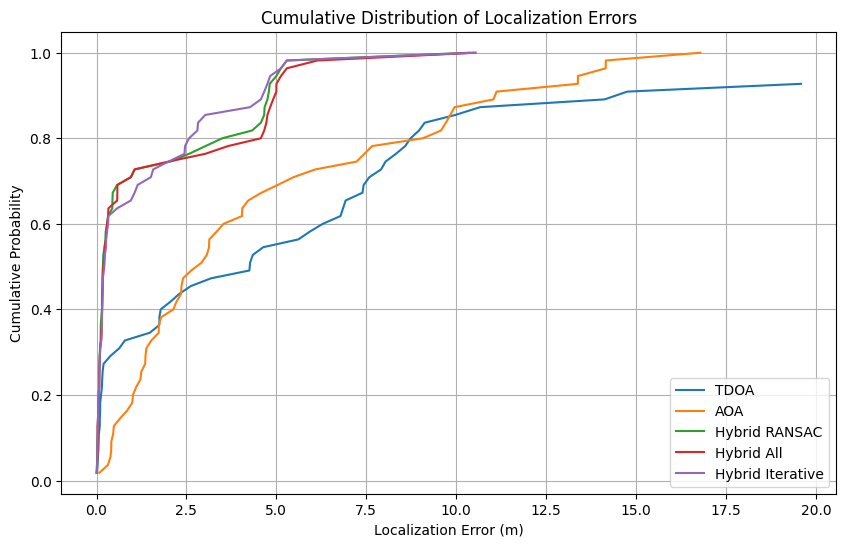

In [122]:
# Plotting the errors
cum = np.arange(1, len(aoa_errors)+1) / len(aoa_errors)
tdoa_errors_plot = np.sort(tdoa_errors)
tdoa_errors_plot = tdoa_errors_plot[:-4]
rmse_tdoa = np.sqrt(np.mean(tdoa_errors_plot**2))
print(f"RMSE TDOA (for valid estimates): {rmse_tdoa:.2f} m")
aoa_errors_plot = np.sort(aoa_errors)
hybrid_ransac_errors_plot = np.sort(hybrid_ransac_errors)
hybrid_all_errors_plot = np.sort(hybrid_all_errors)
hybrid_iterative_errors_plot = np.sort(hybrid_iterative_errors)

plt.figure(figsize=(10, 6))
plt.plot(tdoa_errors_plot, cum[:-4], label='TDOA')
plt.plot(aoa_errors_plot, cum, label='AOA')
plt.plot(hybrid_ransac_errors_plot, cum, label='Hybrid RANSAC')
plt.plot(hybrid_all_errors_plot, cum, label='Hybrid All')
plt.plot(hybrid_iterative_errors_plot, cum, label='Hybrid Iterative')
plt.xlabel("Localization Error (m)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution of Localization Errors")
plt.legend()
plt.grid()
plt.show()